Importing YOLO

In [1]:
from ultralytics import YOLO


Counting combination for each class

In [2]:
import pandas as pd

#read CSV
df = pd.read_csv('dental_dataset/train/_classes.csv')

#combinations for each row
label_cols = ['caries', 'cavity', 'gingivitis', 'gum_swelling', 'healthy', 'plaque']
df['combination'] = df[label_cols].apply(lambda row: '_'.join(row.astype(str)), axis=1)

#counting combinations
print(df['combination'].value_counts())
print(f"\nTotal unique combinations: {df['combination'].nunique()}")

combination
0_1_0_0_0_0    1616
1_1_0_0_0_0     557
1_0_0_0_0_0     531
0_0_1_0_0_0     523
0_0_0_1_0_0     468
0_0_0_0_0_1     426
0_0_0_0_1_0     224
0_1_0_0_1_0     159
1_0_0_0_1_0     131
0_0_0_1_0_1     121
0_1_0_1_0_0      76
0_1_0_0_0_1      27
0_1_0_1_0_1      22
Name: count, dtype: int64

Total unique combinations: 13


Organizing dataset

In [3]:
from pathlib import Path
import shutil
import pandas as pd

source_directory = "./dental_dataset"
output_directory = "./dataset_for_yolo_proper"

def organize_dataset_with_split(split_name):
    """
    Organize images into folders based on class combinations
    """
    source_path = Path(source_directory) / split_name
    output_path = Path(output_directory) / split_name 
    csv_file = source_path / "_classes.csv"
    
    #read csv file
    df = pd.read_csv(csv_file)
    
    #combination lables
    label_cols = ['caries', 'cavity', 'gingivitis', 'gum_swelling', 'healthy', 'plaque']
    df['combination'] = df[label_cols].apply(lambda row: '_'.join(row.astype(str)), axis=1)
    
    #copying images into class folders
    for idx, row in df.iterrows():
        src = source_path / row['filename']
        destination = output_path / row['combination'] / row['filename']
        
        destination.parent.mkdir(parents=True, exist_ok=True)
        
        if src.exists() and not destination.exists():
            shutil.copy(src, destination)
    
    print(f"{len(df)} images in: {split_name}")
    return df['combination'].nunique()

#organizing the dataset
train_classes = organize_dataset_with_split("train")
test_classes = organize_dataset_with_split("test")
valid_classes = organize_dataset_with_split("valid")



4881 images in: train
615 images in: test
692 images in: valid


Loading the model

In [4]:
#loading pretrained yolo classification model
yoloModel = YOLO("yolov8n-cls.pt")

Training the model

In [5]:
yoloModel.train(data = "./dataset_for_yolo_proper", 
                epochs = 20, 
                imgsz =224,
                batch = 16,
                val = True)

Ultralytics 8.4.5  Python-3.13.5 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset_for_yolo_proper, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000234C8927930>
curves: []
curves_results: []
fitness: 0.6004335284233093
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.45375722646713257, 'metrics/accuracy_top5': 0.7471098303794861, 'fitness': 0.6004335284233093}
save_dir: WindowsPath('C:/Personal/University/Year 3/Artificial Intelligence/DentalVision/runs/classify/train6')
speed: {'preprocess': 0.1562695086701851, 'inference': 0.5964862717161792, 'loss': 0.0005917629274819584, 'postprocess': 0.0008041907135179169}
task: 'classify'
top1: 0.45375722646713257
top5: 0.7471098303794861

Comparing loss in each epochs

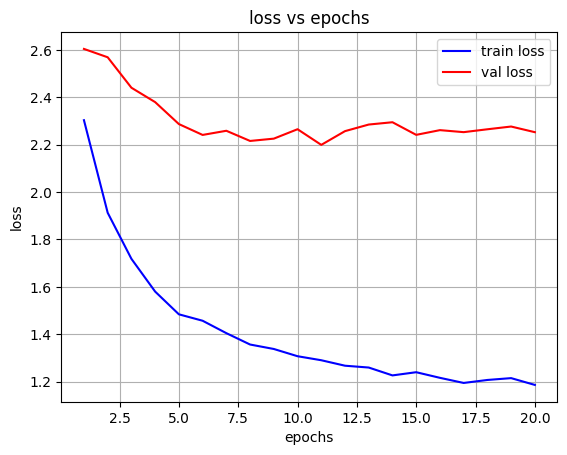

In [11]:
%matplotlib inline
import pandas as pd 
import matplotlib.pyplot as plt 


results = './runs/classify/train6/results.csv'

resultsDf = pd.read_csv(results)

#remove whitespaces 
resultsDf.columns = resultsDf.columns.str.strip()

plt.figure() 
plt.plot(resultsDf['epoch'], resultsDf['train/loss'], label = 'train loss', color = "blue")
plt.plot(resultsDf['epoch'], resultsDf['val/loss'], label = 'val loss', color = "red")
plt.grid() 
plt.title("loss vs epochs")
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()

plt.show()


In [6]:
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import numpy as np


best_model = YOLO("runs/classify/train6/weights/best.pt")  

#getting predictions and probabilites
y_true, y_pred, all_probs = [], [], []
test_path = Path("dataset_for_yolo_proper/test")
class_folders = sorted([f.name for f in test_path.iterdir() if f.is_dir()])

for class_idx, folder in enumerate(sorted(test_path.iterdir())):
    if folder.is_dir():
        for img in folder.glob('*.jpg'):
            result = best_model.predict(str(img), verbose=False)
            y_pred.append(result[0].probs.top1)
            y_true.append(class_idx)
            all_probs.append(result[0].probs.data.cpu().numpy())

#converting to arrays
all_labels = np.array(y_true)
all_preds = np.array(y_pred)
all_probs = np.array(all_probs)

#printing metrics
print("YOLO Test Set Performance")
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Total test images: {len(all_labels)}")


YOLO Test Set Performance
Accuracy:  0.5301
Precision: 0.3778
Recall:    0.3835
F1-Score:  0.3621
Total test images: 615


C:\Users\OMEN\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Confusion matrix

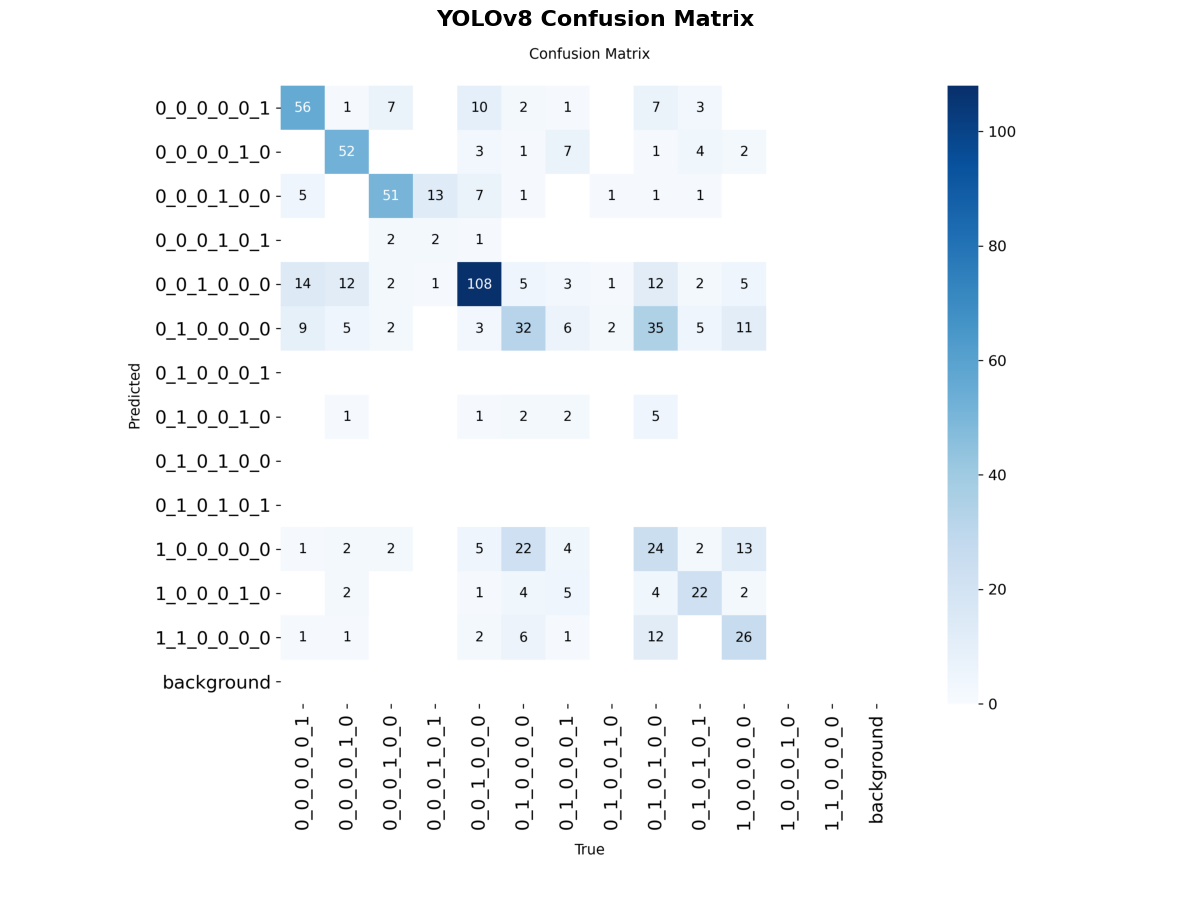

In [1]:
from PIL import Image
import matplotlib.pyplot as plt 

#loading confusion matrix 
confMatrix = "./runs/classify/train6/confusion_matrix.png"

img = Image.open(confMatrix)
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis('off')
plt.title('YOLOv8 Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


ROC curve

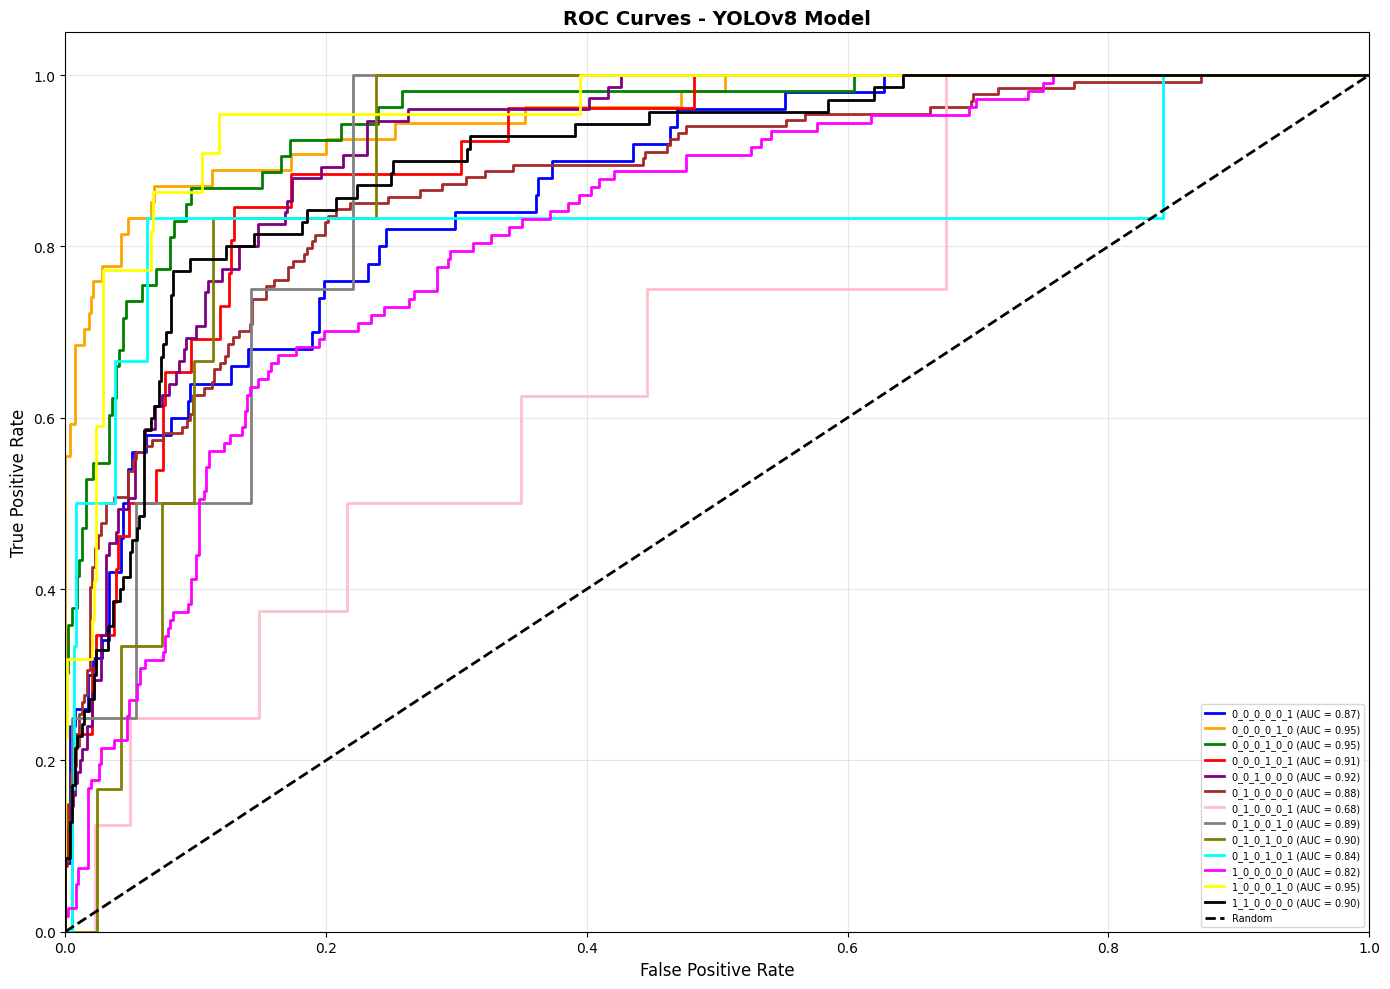


Average AUC: 0.8808


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#getting classes
test_path = Path("dataset_for_yolo_proper/test")
class_folders = sorted([f.name for f in test_path.iterdir() if f.is_dir()])

n_classes = len(class_folders)
y_test_bin = label_binarize(all_labels, classes=range(n_classes))

#Computing ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#Plotting
plt.figure(figsize=(14, 10))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 
          'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{class_folders[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - YOLOv8 Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage AUC: {np.mean(list(roc_auc.values())):.4f}")
